In [2]:
"""
Ligand 47 AutoDock-GPU Analysis 
"""

import os
import re
import glob
import numpy as np
import pandas as pd
import mdtraj as md
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline


try:
    from docking_tools import trajectory_analysis, plotting
    HAS_DOCKING_TOOLS = True
except ImportError:
    print("WARNING: docking_tools not found - interaction fingerprints disabled")
    HAS_DOCKING_TOOLS = False

In [3]:
# ================================================================
# 0.  Constants - identical to Vina script
# ================================================================
CONTACT_ANG = 6.0
CONTACT_NM  = CONTACT_ANG / 10.0
N_BINS      = 20

LIGAND_RESID_PAPER = 21

LIG_HEAVY_PAPER = [294, 295, 296, 297, 298, 299, 300, 301, 302, 303,
                   304, 305, 306, 307, 308, 309, 310, 311, 312, 313,
                   316, 317]
LIG_H_PAPER = [314, 315, 318, 319, 320, 321, 322, 323, 324, 325,
               326, 327, 328, 329, 330, 331, 332, 333, 334, 335,
               336, 337]
assert len(LIG_HEAVY_PAPER) == 22
assert len(LIG_H_PAPER) == 22

LIG_HBOND_DONORS_PAPER = [[312, 314], [312, 315]]
LIG_POS_CHARGES_PAPER  = [312]

RING_BENZENE_PAPER = [300, 301, 302, 303, 304, 305]
RING_5N1_PAPER     = [297, 298, 299, 300, 301]

NH2_H_PAPER       = [314, 315]
NONPOLAR_H_PAPER  = [i for i in LIG_H_PAPER if i not in NH2_H_PAPER]

# AD-GPU PDBQT atom-type tokens
HYDROGEN_TYPES = {'HD', 'H'}                        # polar H
PSEUDO_TYPES   = {'G0',  'G1',  'G2',  'G3'}        # Meeko macrocycle pseudo-atoms (skip)
MACRO_C_TYPES  = {'CG0', 'CG1', 'CG2', 'CG3'}       # Meeko macrocycle REAL carbons (keep as heavy)

In [4]:
# ================================================================
# 1.  Paths 
# ================================================================
PAPER_PDB = '/home/zhihanz/data/DiffDock_copy/data/anjali/ligand47/AutoDock_apo.pdb'

ADGPU_RESULTS_DIR  = '/home/zhihanz/data/autodock_gpu/hpc_results/05072026/docking_results'
ADGPU_LIGAND_NAME  = '47_charged'      # so files are 47_charged.dlg / .xml
PROT_FRAMES_DIR    = '/home/zhihanz/data/autodock_vina/protein_frames/protein_frames_apo'

OUT_DIR = Path('/home/zhihanz/data/autodock_gpu/analysis_paper_compatible')
OUT_DIR.mkdir(exist_ok=True, parents=True)

In [5]:
# ================================================================
# 2.  Helpers
# ================================================================
def compute_bound_fraction_uniform(traj, lig_atom_idx, n_res, cutoff_nm=0.6):
    bound = np.zeros((traj.n_frames, n_res), dtype=float)
    lig_xyz = traj.xyz[:, np.asarray(lig_atom_idx, dtype=int), :]
    for ri, res in enumerate(traj.top.residues):
        if not res.is_protein:
            continue
        if ri >= n_res:
            break
        prot_idx = [a.index for a in res.atoms]
        prot_xyz = traj.xyz[:, prot_idx, :]
        diff = prot_xyz[:, :, np.newaxis, :] - lig_xyz[:, np.newaxis, :, :]
        dists = np.sqrt((diff ** 2).sum(axis=-1))
        min_d = dists.reshape(traj.n_frames, -1).min(axis=1)
        bound[:, ri] = (min_d < cutoff_nm).astype(float)
    return bound.mean(axis=0)


# ----------------------------------------------------------------
# DLG parser: extract lowest-energy MODEL block (heavy + polar H)
# ----------------------------------------------------------------
_RUN_RE     = re.compile(r"DOCKED:\s*USER\s+Run\s*=\s*(\d+)", re.I)
_ENERGY_RE  = re.compile(
    r"DOCKED:\s*USER\s+Estimated Free Energy of Binding\s*=\s*([-+]?\d+\.\d+)",
    re.I)


def parse_adgpu_dlg(filepath):
    """
    Return frame_id, lowest_energy, heavy_xyz (Å), polar_h_xyz (Å).

    Reads ALL DOCKED MODEL blocks in the .dlg, picks the one with the lowest
    'Estimated Free Energy of Binding', then splits its atoms by the AutoDock
    type token in the LAST whitespace field of the PDBQT atom record:

        HD, H              -> polar hydrogen
        G0..G3             -> Meeko macrocycle pseudo-atom (SKIPPED)
        CG0..CG3           -> real macrocycle-break carbon (kept as heavy)
        anything else      -> heavy atom
    """
    fname = Path(filepath).parent.name        # 'frame_07899'
    m_fid = re.search(r"frame_(\d+)", fname)
    frame_id = int(m_fid.group(1)) if m_fid else -1

    models = []
    cur = None
    with open(filepath, "r", errors="ignore") as fh:
        for raw in fh:
            line = raw.rstrip("\n")
            if line.startswith("DOCKED: MODEL"):
                cur = {"run": None, "energy": None,
                       "heavy": [], "polar_h": []}
                continue
            if cur is None:
                continue
            m = _RUN_RE.search(line)
            if m:
                cur["run"] = int(m.group(1))
            m = _ENERGY_RE.search(line)
            if m:
                cur["energy"] = float(m.group(1))

            if line.startswith("DOCKED: ATOM") or line.startswith("DOCKED: HETATM"):
                # strip 'DOCKED: ' prefix => standard PDBQT atom record
                rec = line[len("DOCKED: "):]
                tokens = rec.split()
                atom_type = tokens[-1].strip() if tokens else ""
                try:
                    xyz = [float(rec[30:38]),
                           float(rec[38:46]),
                           float(rec[46:54])]
                except (ValueError, IndexError):
                    continue

                if atom_type in PSEUDO_TYPES:
                    continue                       # ghost atom, no real chemistry
                if atom_type in HYDROGEN_TYPES:
                    cur["polar_h"].append(xyz)
                else:
                    # Real heavy atom (includes CG0/CG1/... macrocycle carbons)
                    cur["heavy"].append(xyz)

            if line.startswith("DOCKED: ENDMDL"):
                models.append(cur)
                cur = None

    if not models:
        return frame_id, None, np.zeros((0, 3)), np.zeros((0, 3))

    valid = [m for m in models if m["energy"] is not None]
    if not valid:
        return frame_id, None, np.zeros((0, 3)), np.zeros((0, 3))

    best = min(valid, key=lambda m: m["energy"])
    return (frame_id,
            best["energy"],
            np.array(best["heavy"]),
            np.array(best["polar_h"]))

In [6]:
# ================================================================
# 3.  Verify topology consistency
# ================================================================
print("=" * 70)
print("STEP 1 - Load paper PDB and verify topology")
print("=" * 70)

ref_paper = md.load(PAPER_PDB)
print(f"Paper PDB: {ref_paper.n_atoms} atoms")

prot_paper_idx    = ref_paper.top.select(f"resid 0 to {LIGAND_RESID_PAPER - 1}")
lig_paper_idx_all = ref_paper.top.select(f"resid {LIGAND_RESID_PAPER}")
print(f"Protein atoms (paper) : {len(prot_paper_idx)}")
print(f"Ligand atoms (paper)  : {len(lig_paper_idx_all)} "
      f"({len(LIG_HEAVY_PAPER)} heavy + {len(LIG_H_PAPER)} H)")

test_prot_files = sorted(glob.glob(os.path.join(PROT_FRAMES_DIR, "*.pdb")))
if not test_prot_files:
    raise SystemExit(f"No protein frames found in {PROT_FRAMES_DIR}")
prot_t = md.load(test_prot_files[0])
print(f"Your protein file     : {prot_t.n_atoms} atoms  "
      f"{'OK' if prot_t.n_atoms == len(prot_paper_idx) else 'mismatch'}")

STEP 1 - Load paper PDB and verify topology
Paper PDB: 338 atoms
Protein atoms (paper) : 294
Ligand atoms (paper)  : 44 (22 heavy + 22 H)
Your protein file     : 294 atoms  OK


In [7]:
# ================================================================
# 4.  Parse all AD-GPU .dlg files (lowest-energy run per frame)
# ================================================================
print("\n" + "=" * 70)
print("STEP 2 - Parse AD-GPU .dlg files (lowest-energy run per frame)")
print("=" * 70)

dlg_files = sorted(glob.glob(os.path.join(
    ADGPU_RESULTS_DIR, "frame_*", f"{ADGPU_LIGAND_NAME}.dlg")))
print(f"Found {len(dlg_files)} .dlg files")

records, failed = [], []
for fp in dlg_files:
    try:
        fid, energy, heavy, polar_h = parse_adgpu_dlg(fp)
        if energy is None or len(heavy) != len(LIG_HEAVY_PAPER):
            failed.append((fp, f"energy={energy}, n_heavy={len(heavy)}"))
            continue
        records.append((fid, energy, heavy, polar_h))
    except Exception as e:
        failed.append((fp, str(e)))

records.sort(key=lambda x: x[0])
print(f"Parsed: {len(records)}, Failed: {len(failed)}")
if failed[:5]:
    print("First few failures:")
    for fp, msg in failed[:5]:
        print(f"  {fp}: {msg}")

if not records:
    raise SystemExit("No usable records — aborting")

adg_frame_ids = np.array([r[0] for r in records])
adg_scores    = np.array([r[1] for r in records])
print(f"Energy range: {adg_scores.min():.3f} to {adg_scores.max():.3f} kcal/mol")
print(f"Median: {np.median(adg_scores):.3f}, Mean: {adg_scores.mean():.3f}")


# ----------------------------------------------------------------
# Sanity check: NH2 N-H distance in the AD-GPU pose.
# Atom 312 (paper) is the NH2 nitrogen; its position in LIG_HEAVY_PAPER
# tells us where in `heavy` array it lives. The two polar H's should be
# ~1.0 Å away (covalent N-H bond).
# ----------------------------------------------------------------
fid0, _, heavy0, polar_h0 = records[0]
n_pos_in_heavy = LIG_HEAVY_PAPER.index(312)
n_xyz_chk      = heavy0[n_pos_in_heavy]

print(f"\n[sanity] frame {fid0}: heavy[{n_pos_in_heavy}] (paper atom 312, NH2 N) = {n_xyz_chk}")
if len(polar_h0) > 0:
    dists = np.linalg.norm(polar_h0 - n_xyz_chk, axis=1)
    print(f"[sanity] N-(polar H) distances: {dists}")
    if dists.max() > 1.5 or dists.min() < 0.7:
        print("[sanity] WARNING: polar H is not bonded to atom 312 — "
              "heavy-atom ordering in the AD-GPU PDBQT may differ from the paper PDB.")
    else:
        print("[sanity] OK — NH2 hydrogens are bonded to N (paper atom 312).")
else:
    print("[sanity] no polar H in this frame")


STEP 2 - Parse AD-GPU .dlg files (lowest-energy run per frame)
Found 20018 .dlg files
Parsed: 20018, Failed: 0
Energy range: -8.100 to -2.780 kcal/mol
Median: -4.780, Mean: -4.836

[sanity] frame 0: heavy[18] (paper atom 312, NH2 N) = [-12.179   4.772  34.106]
[sanity] N-(polar H) distances: [1.01931987 1.01951999]
[sanity] OK — NH2 hydrogens are bonded to N (paper atom 312).


In [8]:
# ================================================================
# 5.  Build trajectory using paper PDB topology
# ================================================================
print("\n" + "=" * 70)
print("STEP 3 - Build AD-GPU trajectory with paper PDB topology")
print("=" * 70)

n_frames = len(records)
xyz_adg  = np.zeros((n_frames, ref_paper.n_atoms, 3), dtype=np.float32)

# Non-polar H placement: keep paper-PDB offsets relative to heavy centroid
ref_paper_xyz_ang     = ref_paper.xyz[0] * 10.0
heavy_centroid_paper  = ref_paper_xyz_ang[LIG_HEAVY_PAPER].mean(axis=0)
nonpolar_h_offset     = ref_paper_xyz_ang[NONPOLAR_H_PAPER] - heavy_centroid_paper

n_match_2h, n_other, missing_prot = 0, 0, 0

for i, (fid, _, heavy, polar_h) in enumerate(records):
    # 1. Protein from per-frame file
    prot_pdb = os.path.join(PROT_FRAMES_DIR,
                            f"protein_only_frame_{fid:05d}_fasudil_apo.pdb")
    if os.path.exists(prot_pdb):
        prot_t = md.load(prot_pdb)
        n_copy = min(prot_t.n_atoms, len(prot_paper_idx))
        xyz_adg[i, prot_paper_idx[:n_copy], :] = prot_t.xyz[0, :n_copy, :]
    else:
        xyz_adg[i, prot_paper_idx, :] = ref_paper.xyz[0, prot_paper_idx, :]
        missing_prot += 1

    # 2. Ligand heavy atoms (Å -> nm)
    xyz_adg[i, LIG_HEAVY_PAPER, :] = heavy / 10.0

    # 3. Polar H (NH2 hydrogens)
    if len(polar_h) == 2:
        xyz_adg[i, NH2_H_PAPER, :] = polar_h / 10.0
        n_match_2h += 1
    elif len(polar_h) > 0:
        n = min(len(polar_h), 2)
        xyz_adg[i, NH2_H_PAPER[:n], :] = polar_h[:n] / 10.0
        n_other += 1

    # 4. Non-polar H from paper template, anchored to current heavy centroid
    heavy_centroid = (heavy / 10.0).mean(axis=0)
    xyz_adg[i, NONPOLAR_H_PAPER, :] = heavy_centroid + nonpolar_h_offset / 10.0

print(f"Frames with 2 polar H : {n_match_2h}")
print(f"Frames with other H#  : {n_other}")
print(f"Missing protein frames: {missing_prot}")

adg_traj = md.Trajectory(xyz_adg, ref_paper.topology)
print(f"\nAD-GPU trajectory: {adg_traj.n_frames} frames, {adg_traj.n_atoms} atoms")

# Sanity check on the assembled trajectory
n_xyz  = adg_traj.xyz[0, 312, :] * 10
h1_xyz = adg_traj.xyz[0, 314, :] * 10
h2_xyz = adg_traj.xyz[0, 315, :] * 10
print(f"Frame 0 N-H1: {np.linalg.norm(n_xyz - h1_xyz):.3f} Å, "
      f"N-H2: {np.linalg.norm(n_xyz - h2_xyz):.3f} Å")


STEP 3 - Build AD-GPU trajectory with paper PDB topology
Frames with 2 polar H : 20018
Frames with other H#  : 0
Missing protein frames: 0

AD-GPU trajectory: 20018 frames, 338 atoms
Frame 0 N-H1: 1.019 Å, N-H2: 1.020 Å


In [9]:
# ================================================================
# 6.  Bound fraction (heavy atoms only)
# ================================================================
print("\n" + "=" * 70)
print("STEP 4 - Compute bound fraction (uniform)")
print("=" * 70)

n_res_adg = LIGAND_RESID_PAPER
bf_adg_ensemble = compute_bound_fraction_uniform(
    adg_traj, np.array(LIG_HEAVY_PAPER), n_res_adg, CONTACT_NM)
total_bf_adg = bf_adg_ensemble[:20].mean()
print(f"AD-GPU total bound fraction: {total_bf_adg:.3f}")


STEP 4 - Compute bound fraction (uniform)
AD-GPU total bound fraction: 0.533



STEP 5 - Interaction fingerprints (paper-style)
Bin  1: 1000 frames | hphob=3.945 | aro=0.244 | hbond=0.407 | charge=0.682 | 
Bin  2: 1000 frames | hphob=4.375 | aro=0.217 | hbond=0.457 | charge=0.688 | 
Bin  3: 1000 frames | hphob=3.895 | aro=0.189 | hbond=0.426 | charge=0.682 | 
Bin  4: 1000 frames | hphob=4.570 | aro=0.235 | hbond=0.445 | charge=0.618 | 
Bin  5: 1000 frames | hphob=4.107 | aro=0.219 | hbond=0.435 | charge=0.647 | 
Bin  6: 1000 frames | hphob=4.258 | aro=0.246 | hbond=0.420 | charge=0.667 | 
Bin  7: 1000 frames | hphob=4.448 | aro=0.252 | hbond=0.432 | charge=0.676 | 
Bin  8: 1000 frames | hphob=4.690 | aro=0.313 | hbond=0.479 | charge=0.653 | 
Bin  9: 1000 frames | hphob=4.288 | aro=0.291 | hbond=0.455 | charge=0.614 | 
Bin 10: 1000 frames | hphob=4.476 | aro=0.275 | hbond=0.468 | charge=0.609 | 
Bin 11: 1000 frames | hphob=4.460 | aro=0.272 | hbond=0.421 | charge=0.622 | 
Bin 12: 1000 frames | hphob=4.679 | aro=0.300 | hbond=0.540 | charge=0.617 | 
Bin 13: 1000 fr

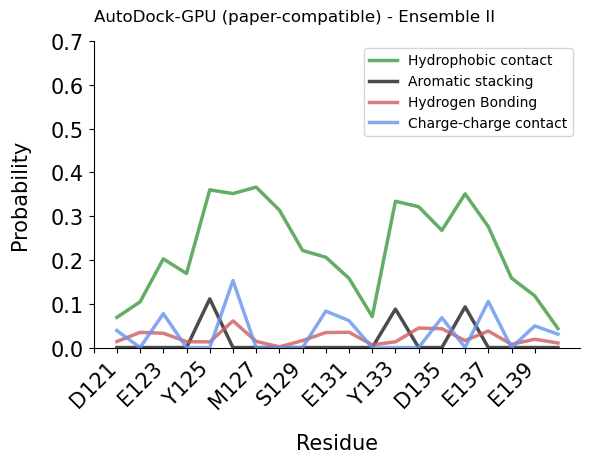

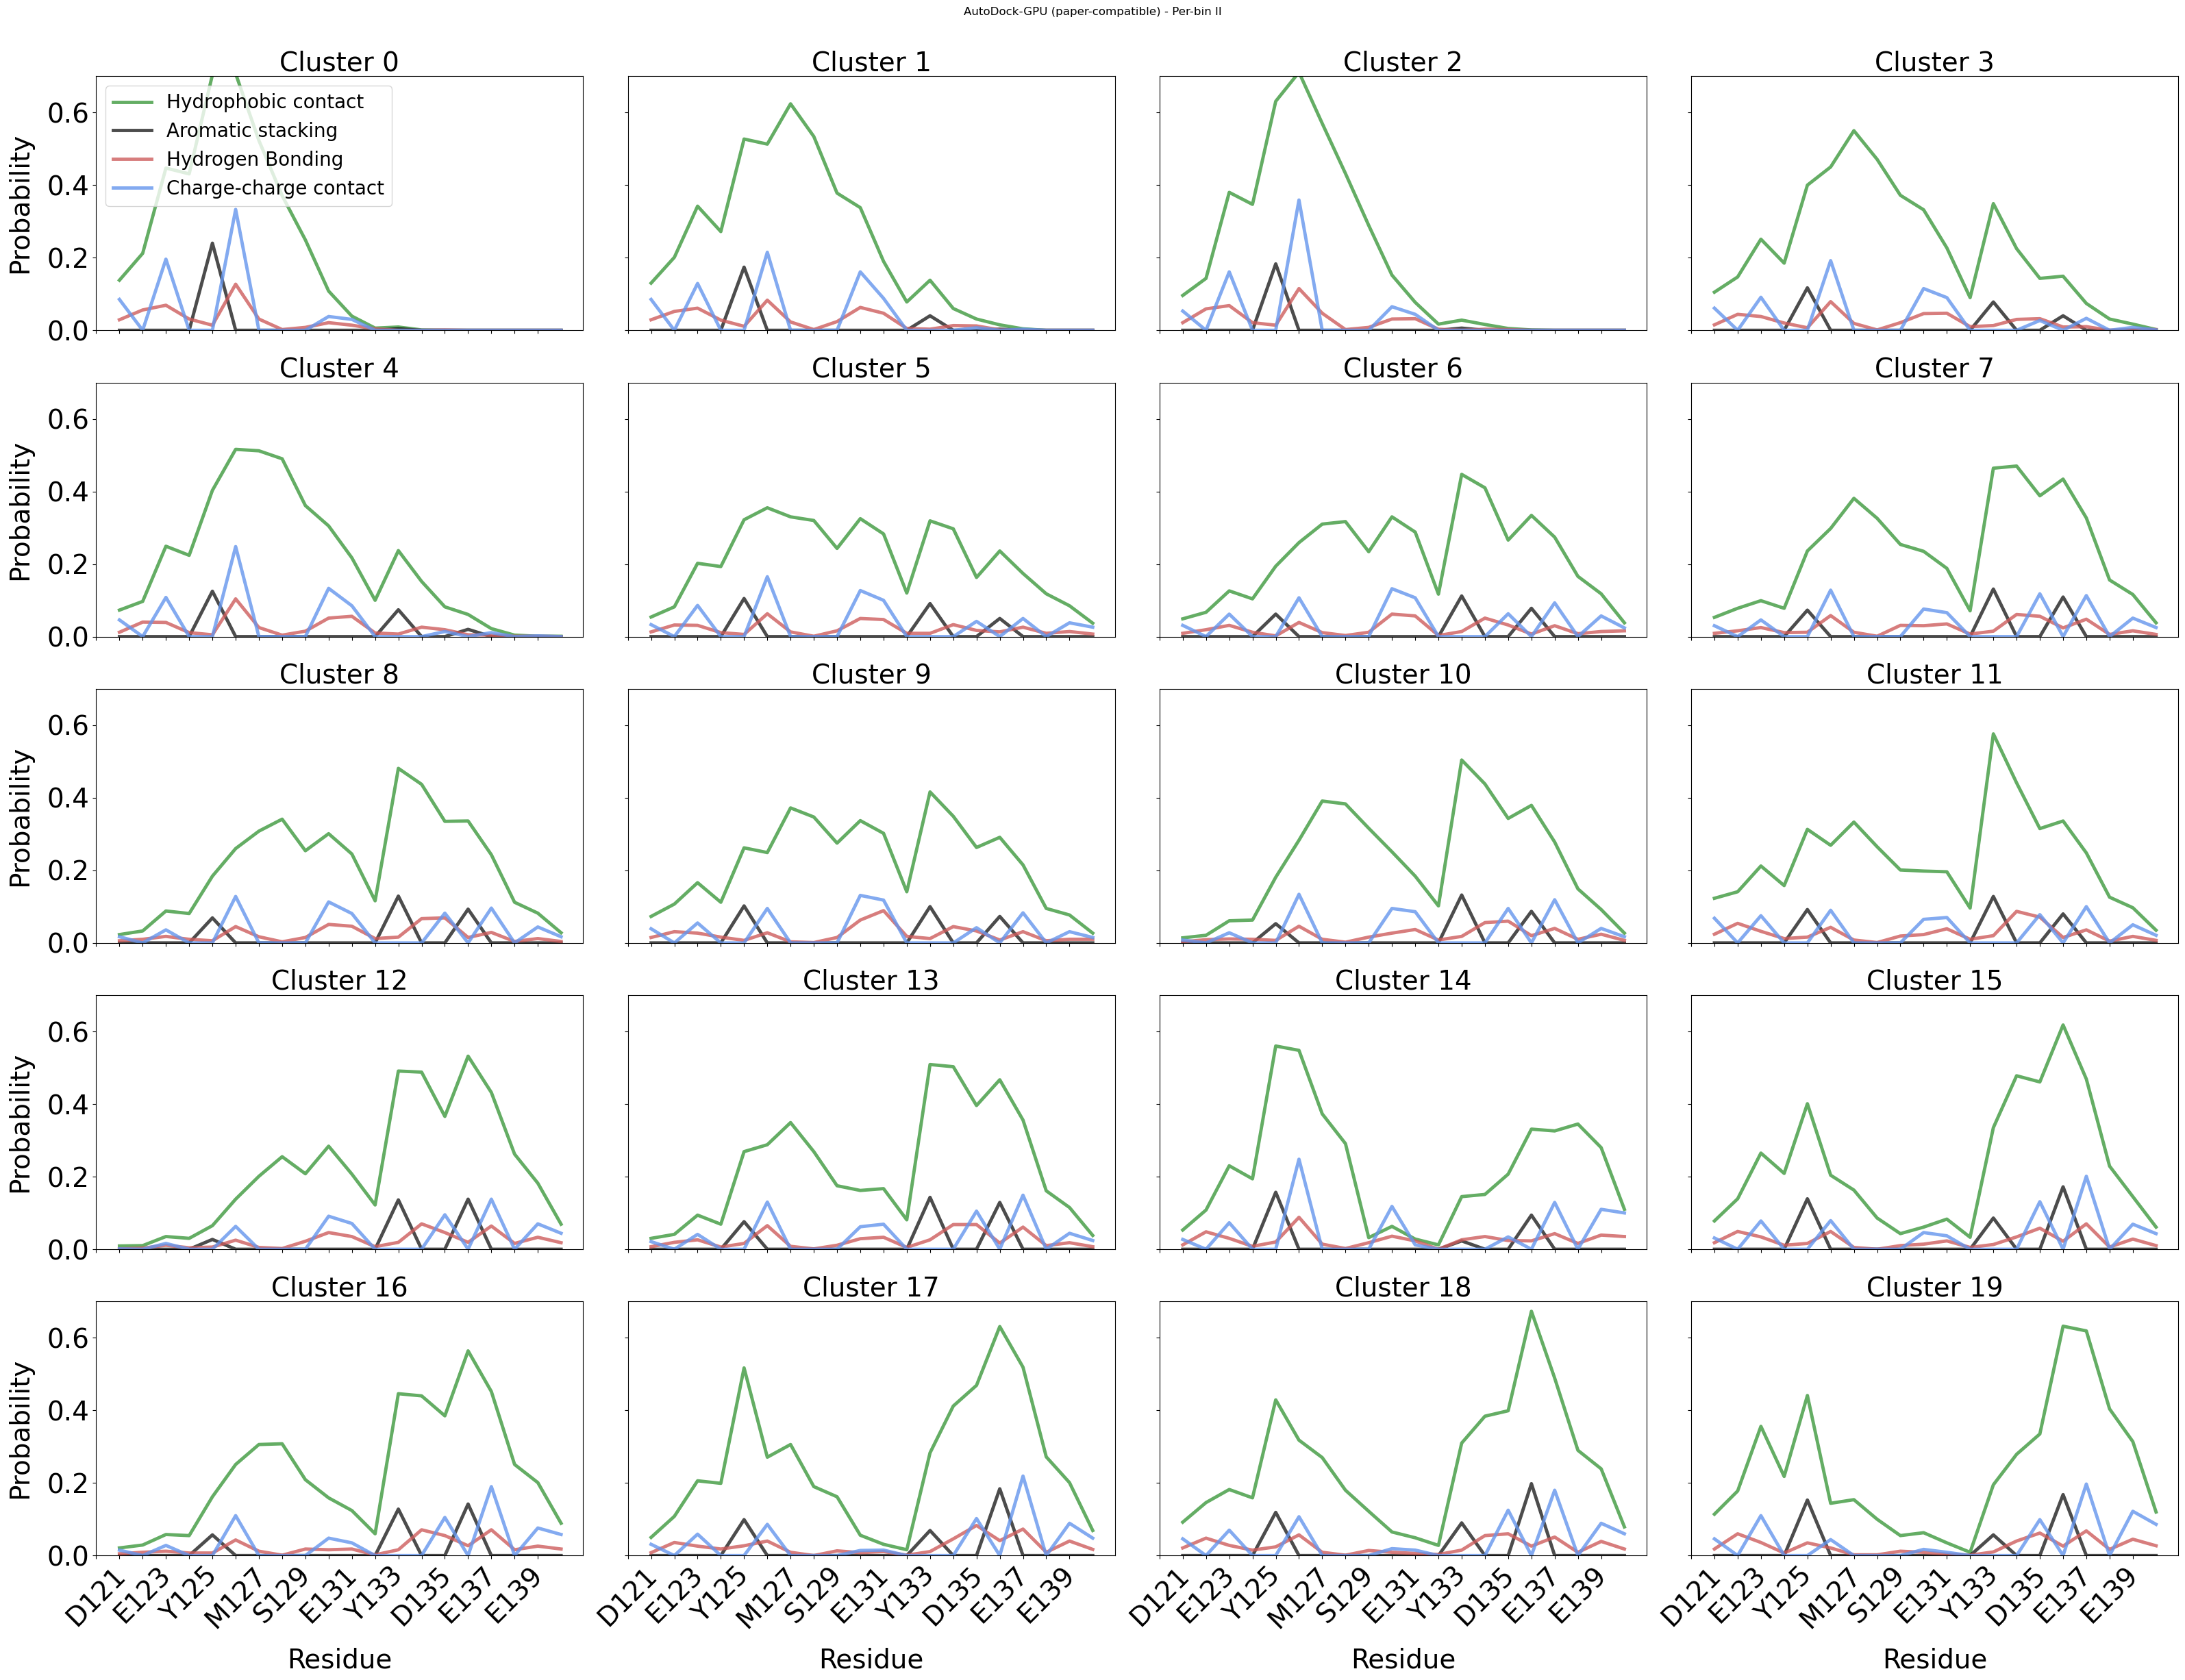

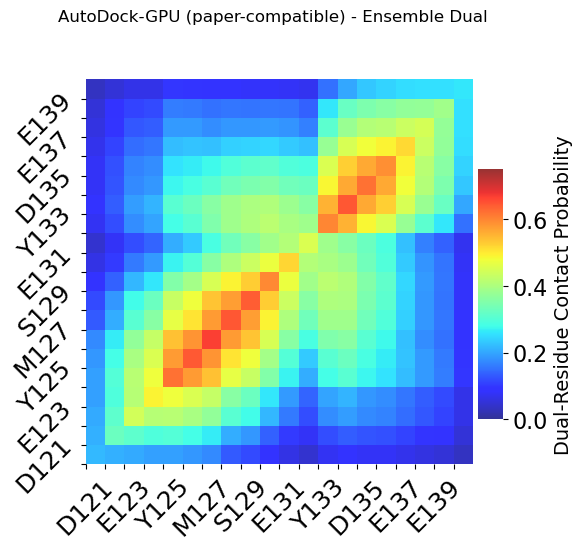

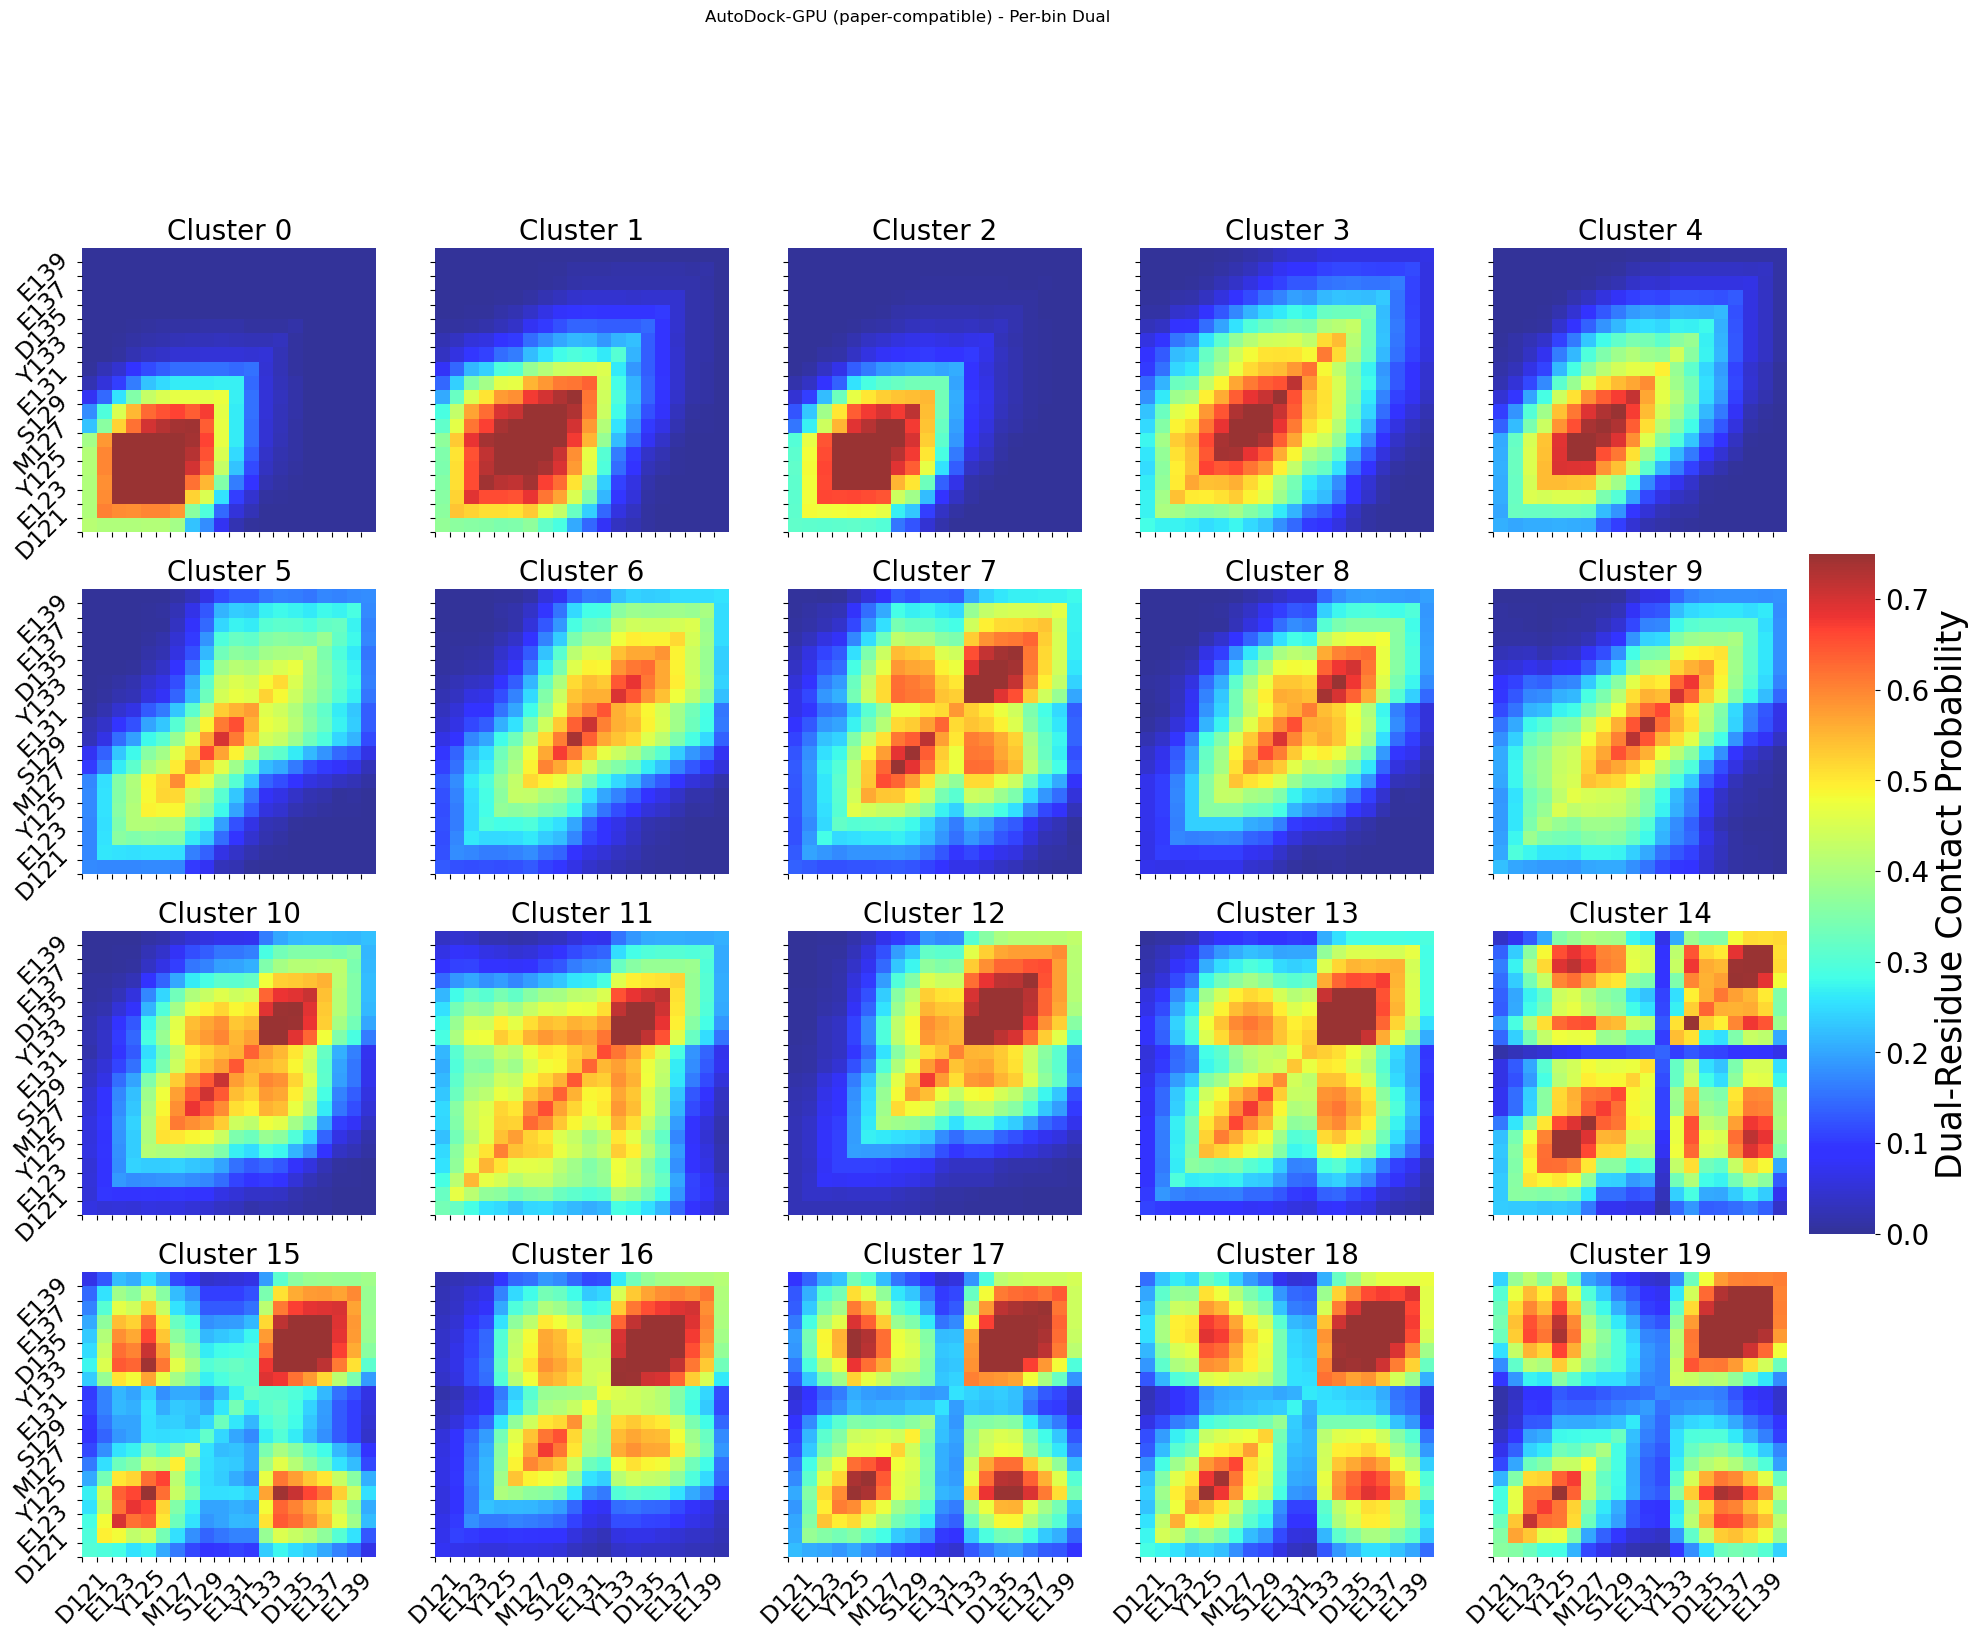

In [10]:
# ================================================================
# 7.  Interaction fingerprints (paper-style, 20 clusters)
# ================================================================
if HAS_DOCKING_TOOLS:
    print("\n" + "=" * 70)
    print("STEP 5 - Interaction fingerprints (paper-style)")
    print("=" * 70)

    bin_size  = adg_traj.n_frames // N_BINS
    bin_trajs = [adg_traj[i*bin_size:(i+1)*bin_size] for i in range(N_BINS)]
    bin_pop   = np.ones(N_BINS) / N_BINS

    contacts = {'hphob': [], 'aro': [], 'hbond': [], 'charge': [], 'dual': []}

    for i, traj in enumerate(bin_trajs):
        print(f"Bin {i+1:>2}: {traj.n_frames} frames", end=" | ")

        try:
            hp = trajectory_analysis.hphob_contacts(traj, LIGAND_RESID_PAPER)
            contacts['hphob'].append(hp)
            print(f"hphob={hp.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"hphob ERR:{e}", end=" | ")
            contacts['hphob'].append(np.zeros((traj.n_frames, 20)))

        try:
            ar = trajectory_analysis.aro_contacts(
                traj, ligand_rings=[RING_BENZENE_PAPER])
            contacts['aro'].append(ar)
            print(f"aro={ar.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"aro ERR:{e}", end=" | ")
            contacts['aro'].append(np.zeros((traj.n_frames, 20)))

        try:
            hb = trajectory_analysis.hbond(
                traj, LIGAND_RESID_PAPER,
                lig_hbond_donors=LIG_HBOND_DONORS_PAPER)
            contacts['hbond'].append(hb)
            print(f"hbond={hb.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"hbond ERR:{e}", end=" | ")
            contacts['hbond'].append(np.zeros((traj.n_frames, 20)))

        try:
            ch = trajectory_analysis.charge_contacts(
                traj, Ligand_Pos_Charges=LIG_POS_CHARGES_PAPER)
            contacts['charge'].append(ch)
            print(f"charge={ch.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"charge ERR:{e}", end=" | ")
            contacts['charge'].append(np.zeros((traj.n_frames, 20)))

        try:
            du = trajectory_analysis.dual_contact(
                traj, residue_idx=LIGAND_RESID_PAPER)
            contacts['dual'].append(du)
        except Exception:
            contacts['dual'].append(None)
        print()

    # Reshape for plotting
    contacts_plot = {}
    for key in ['hphob', 'aro', 'hbond', 'charge']:
        per_bin_means = [arr[:, :20].mean(axis=0) if arr is not None
                         else np.zeros(20) for arr in contacts[key]]
        contacts_plot[key] = np.array(per_bin_means)[:, np.newaxis, :]

    dual_v = [d for d in contacts['dual'] if d is not None]
    if dual_v:
        ds = dual_v[0].shape
        contacts_plot['dual'] = np.stack([
            d if d is not None else np.zeros(ds) for d in contacts['dual']])

    # Plots
    plotting.plot_ensemble_ii(contacts_plot, bin_pop[:, np.newaxis])
    plt.suptitle('AutoDock-GPU (paper-compatible) - Ensemble II', y=1.02)
    plt.savefig(OUT_DIR / 'ensemble_ii_adgpu.png', dpi=150, bbox_inches='tight')
    plt.show()

    plotting.plot_clus_ii(contacts_plot)
    plt.suptitle('AutoDock-GPU (paper-compatible) - Per-bin II', y=1.02)
    plt.savefig(OUT_DIR / 'clus_ii_adgpu.png', dpi=150, bbox_inches='tight')
    plt.show()

    if 'dual' in contacts_plot:
        plotting.plot_ensemble_dual(contacts_plot['dual'], bin_pop)
        plt.suptitle('AutoDock-GPU (paper-compatible) - Ensemble Dual', y=1.02)
        plt.savefig(OUT_DIR / 'ensemble_dual_adgpu.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        plotting.plot_clus_dual(contacts_plot['dual'])
        plt.suptitle('AutoDock-GPU (paper-compatible) - Per-bin Dual', y=1.02)
        plt.savefig(OUT_DIR / 'clus_dual_adgpu.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

In [11]:
# ================================================================
# 8.  Save
# ================================================================
np.savez(OUT_DIR / 'adgpu_results.npz',
         frame_ids=adg_frame_ids,
         scores=adg_scores,
         bound_fraction=bf_adg_ensemble[:20])

master = pd.DataFrame({'frame_id': adg_frame_ids, 'adgpu_score': adg_scores})
master.to_csv(OUT_DIR / 'master_adgpu_47.csv', index=False)

print(f"\nAll outputs in: {OUT_DIR}")
print("\nNotes:")
print("  - AD-GPU energies use AutoDock4 scoring; absolute kcal/mol values are")
print("    NOT directly comparable to Vina, but per-frame trends should be.")
print("  - The 'best' pose per frame here is the lowest-energy LGA run.")


All outputs in: /home/zhihanz/data/autodock_gpu/analysis_paper_compatible

Notes:
  - AD-GPU energies use AutoDock4 scoring; absolute kcal/mol values are
    NOT directly comparable to Vina, but per-frame trends should be.
  - The 'best' pose per frame here is the lowest-energy LGA run.
